# Phase 1: Dataset Inspection

In this phase we do not train a model yet. We first check whether the dataset is present, readable, balanced, and safe to use.

Why this matters: a deep learning model can only learn correctly if the input data is organized correctly. Bad paths, corrupted images, or wrong class labels can silently ruin training.

## 1. Setup

Import the small set of libraries needed for dataset inspection. Finds the project folder and points to the dataset folder.

In [7]:
from collections import Counter
from pathlib import Path
from typing import Dict, List, Optional, Tuple

from IPython.display import display
from PIL import Image, ImageDraw, UnidentifiedImageError

# If the notebook is opened from the notebooks folder, the project root is one folder above it.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {DATASET_DIR}")

Project root: c:\Users\smart\Coding World\SpectiqAI
Dataset directory: c:\Users\smart\Coding World\SpectiqAI\dataset


Python now knows where your project and dataset are. Next step: check the class folders inside the dataset.

## 2. Verify Dataset Structure

Confirm that the dataset folder exists and contains class folders. Checks for the two expected folders: normal images and tumor images.

In [8]:
CLASS_DIRS: Dict[str, str] = {
    "Normal": "Hyperspectral_normal_images",
    "Tumor": "Hyperspectral_tumor_images",
}

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {DATASET_DIR}")

available_folders = sorted(path.name for path in DATASET_DIR.iterdir() if path.is_dir())
print("Available folders in dataset:")
for folder_name in available_folders:
    print(f"- {folder_name}")

class_paths: Dict[str, Path] = {}
for class_name, folder_name in CLASS_DIRS.items():
    class_path = DATASET_DIR / folder_name
    if not class_path.exists():
        raise FileNotFoundError(f"Missing folder for {class_name}: {class_path}")
    class_paths[class_name] = class_path
    print(f"Found {class_name} folder: {class_path}")

Available folders in dataset:
- Hyperspectral_normal_images
- Hyperspectral_tumor_images
Found Normal folder: c:\Users\smart\Coding World\SpectiqAI\dataset\Hyperspectral_normal_images
Found Tumor folder: c:\Users\smart\Coding World\SpectiqAI\dataset\Hyperspectral_tumor_images


The notebook can safely map folder names to class labels. Next step: count the image files in each class.

## 3. Count Images and File Types

Count how many images are available in each class. Collects `.jpg`, `.jpeg`, and `.png` files without loading them into memory.

In [9]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def collect_image_paths(folder: Path) -> List[Path]:
    """Return image paths in one class folder without loading image contents."""
    return sorted(
        path for path in folder.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

image_paths_by_class: Dict[str, List[Path]] = {
    class_name: collect_image_paths(class_path)
    for class_name, class_path in class_paths.items()
}

all_image_paths: List[Tuple[str, Path]] = []
for class_name, image_paths in image_paths_by_class.items():
    all_image_paths.extend((class_name, image_path) for image_path in image_paths)

for class_name, image_paths in image_paths_by_class.items():
    extension_counts = Counter(path.suffix.lower() for path in image_paths)
    print(f"{class_name}: {len(image_paths)} images")
    print(f"  Extensions: {dict(extension_counts)}")

print(f"Total images: {len(all_image_paths)}")

Normal: 5000 images
  Extensions: {'.jpg': 5000}
Tumor: 5000 images
  Extensions: {'.jpg': 5000}
Total images: 10000


The dataset is large enough and balanced enough for the next phases. Next step: confirm image dimensions and detect corrupted files.

## 4. Verify Image Sizes and Corrupted Images

Make sure every image can be opened and has valid dimensions. Opens one image at a time, verifies it with Pillow, records image sizes, and stores corrupted file paths if any are found.

In [10]:
def inspect_image(image_path: Path) -> Tuple[bool, Optional[Tuple[int, int]], Optional[str]]:
    """Check whether an image is readable and return its size if valid."""
    try:
        with Image.open(image_path) as image:
            image.verify()

        # Reopen after verify because Pillow closes internal image data after verification.
        with Image.open(image_path) as image:
            return True, image.size, None
    except (UnidentifiedImageError, OSError, ValueError) as error:
        return False, None, str(error)


size_counts: Counter[Tuple[int, int]] = Counter()
corrupted_images: List[Tuple[str, Path, str]] = []

for index, (class_name, image_path) in enumerate(all_image_paths, start=1):
    is_valid, image_size, error_message = inspect_image(image_path)

    if is_valid and image_size is not None:
        size_counts[image_size] += 1
    else:
        corrupted_images.append((class_name, image_path, error_message or "Unknown error"))

    if index % 1000 == 0:
        print(f"Checked {index} / {len(all_image_paths)} images...")

print(f"Finished checking {len(all_image_paths)} images.")
print(f"Corrupted images: {len(corrupted_images)}")
print("Most common image sizes:")
for (width, height), count in size_counts.most_common(10):
    print(f"- {width} x {height}: {count} images")

if corrupted_images:
    print("First corrupted files:")
    for class_name, image_path, error_message in corrupted_images[:10]:
        print(f"- {class_name}: {image_path.name} -> {error_message}")

Checked 1000 / 10000 images...
Checked 2000 / 10000 images...
Checked 3000 / 10000 images...
Checked 4000 / 10000 images...
Checked 5000 / 10000 images...
Checked 6000 / 10000 images...
Checked 7000 / 10000 images...
Checked 8000 / 10000 images...
Checked 9000 / 10000 images...
Checked 10000 / 10000 images...
Finished checking 10000 images.
Corrupted images: 0
Most common image sizes:
- 512 x 512: 10000 images


If all files are valid, we can use them in a PyTorch dataset later. If corrupted files exist, we should exclude them before training. Next step: visualize sample images from each class to check labels with human eyes.

## 5. Visualize Samples

Look at a few images from each class. Creates one simple contact sheet using Pillow and displays it inside the notebook.

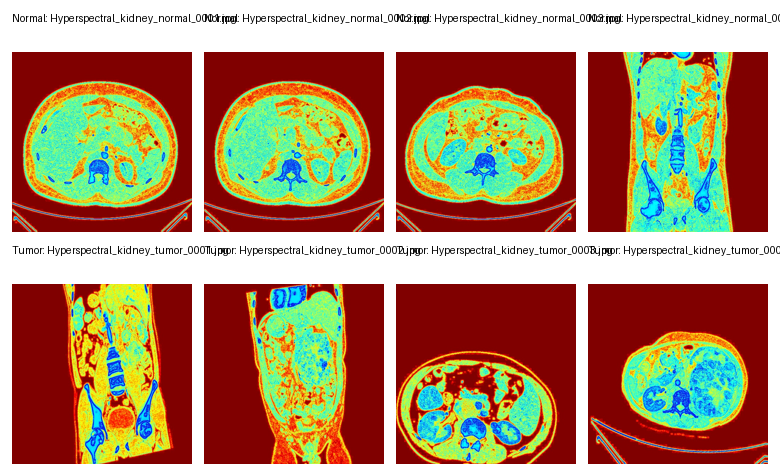

In [11]:
def make_contact_sheet(image_paths_by_class: Dict[str, List[Path]], samples_per_class: int = 4) -> Image.Image:
    """Create a small image grid without needing Matplotlib."""
    thumbnail_size = (180, 180)
    label_height = 40
    padding = 12
    class_names = list(image_paths_by_class.keys())

    sheet_width = samples_per_class * (thumbnail_size[0] + padding) + padding
    sheet_height = len(class_names) * (thumbnail_size[1] + label_height + padding) + padding
    sheet = Image.new("RGB", (sheet_width, sheet_height), color="white")
    draw = ImageDraw.Draw(sheet)

    for row_index, class_name in enumerate(class_names):
        row_top = padding + row_index * (thumbnail_size[1] + label_height + padding)
        for column_index, image_path in enumerate(image_paths_by_class[class_name][:samples_per_class]):
            column_left = padding + column_index * (thumbnail_size[0] + padding)
            with Image.open(image_path) as image:
                thumbnail = image.convert("RGB")
                thumbnail.thumbnail(thumbnail_size)

            x_offset = column_left + (thumbnail_size[0] - thumbnail.width) // 2
            y_offset = row_top + label_height + (thumbnail_size[1] - thumbnail.height) // 2
            draw.text((column_left, row_top), f"{class_name}: {image_path.name}", fill="black")
            sheet.paste(thumbnail, (x_offset, y_offset))

    return sheet


sample_sheet = make_contact_sheet(image_paths_by_class, samples_per_class=4)
display(sample_sheet)

Visual inspection helps catch obvious label or loading problems before training. Next step: plot the class distribution to confirm balance.

## 6. Verify Class Distribution

Check whether the dataset is balanced. Prints image counts and a simple text bar for each class.

In [12]:
class_counts = {
    class_name: len(image_paths)
    for class_name, image_paths in image_paths_by_class.items()
}

max_count = max(class_counts.values()) if class_counts else 1
bar_width = 40

for class_name, count in class_counts.items():
    filled_width = round((count / max_count) * bar_width)
    bar = "#" * filled_width
    print(f"{class_name:>6}: {count:5d} images | {bar}")

print(class_counts)

Normal:  5000 images | ########################################
 Tumor:  5000 images | ########################################
{'Normal': 5000, 'Tumor': 5000}


A balanced dataset makes the first training phase simpler because accuracy will be less misleading than it would be on an imbalanced dataset. Next step: if all Phase 1 checks pass, move to Phase 2: preprocessing, train/validation/test split, augmentation, and PyTorch DataLoaders.

## Phase 1 Completion Checklist

Before moving to Phase 2, confirm these results:

- Dataset folder exists.
- Normal class folder exists.
- Tumor class folder exists.
- Total images are counted correctly.
- Corrupted image count is acceptable, ideally zero.
- Image sizes are known.
- Sample images display correctly.
- Class distribution is balanced.